# Synchronizability of islet networks and the effect of network size

In [1]:
import matplotlib.pyplot as plt
#from matplotlib.colors import to_rgb, to_rgba
import networkx as nx
import numpy as np
import os
import seaborn as sb
#import random
#from labellines import labelLines 

sb.set_context("paper")
#sb.set_theme(style="ticks")

plt.rc('text', usetex=True)

In [2]:
# These are the "Tableau 20" colors as RGB.
tableau20 = [(31, 119, 180), (174, 199, 232), (255, 127, 14), (255, 187, 120),
             (44, 160, 44), (152, 223, 138), (214, 39, 40), (255, 152, 150),
             (148, 103, 189), (197, 176, 213), (140, 86, 75), (196, 156, 148),
             (227, 119, 194), (247, 182, 210), (127, 127, 127), (199, 199, 199),
             (188, 189, 34), (219, 219, 141), (23, 190, 207), (158, 218, 229)]

# Scale the RGB values to the [0, 1] range, which is the format matplotlib accepts.
for i in range(len(tableau20)):
    r, g, b = tableau20[i]
    tableau20[i] = (r / 255., g / 255., b / 255.)

Calculate the eigen-ratio for an islet network (defined as the ratio between the largest and the smallest nonzero Laplacian eigenvalues)

In [3]:
# import islet network 
G = nx.read_gml("size43_it73_er5.72.gml")
#G = nx.read_gml("size8797_it40_er7.33.gml")

# string to float
for u,v in G.edges:
    G[u][v]["weight"]=float(G[u][v]["weight"])

#print(nx.get_edge_attributes(G, "weight"))
#G = nx.convert_node_labels_to_integers(G)
#N = G.number_of_nodes()
#print(nx.laplacian_matrix(G).toarray())

print(nx.is_connected(G))

# compute the Laplacian eigenvalues
eigs = nx.laplacian_spectrum(G, weight='weight')
print(eigs)
eig_ratio = eigs[-1]/eigs[1]
print(eig_ratio)

FileNotFoundError: [Errno 2] No such file or directory: 'size43_it73_er5.72.gml'

Repeat the eigen-ratio calculation for all islet networks

In [4]:
# store network size and eigen-ratio
data = np.zeros((2,219))
i = 0
# import islet networks 
directory = '.'
# iterate over files in that directory
for filename in os.listdir(directory):
    f = os.path.join(directory, filename)
    # checking if it is a file
    if os.path.isfile(f):
        #print(f)
        G = nx.read_gml(f)
        N = G.number_of_nodes()
        for u,v in G.edges:
            G[u][v]["weight"]=float(G[u][v]["weight"])
        # if the network is connected, calculate its eigen-ratio
        if nx.is_connected(G):
            eigs = nx.laplacian_spectrum(G, weight='weight')
            eig_ratio = eigs[-1]/eigs[1]
            data[0,i] = N
            data[1,i] = eig_ratio
            i = i+1


NetworkXError: input is not ASCII-encoded

Scatter plot of eigen-ratio vs network size

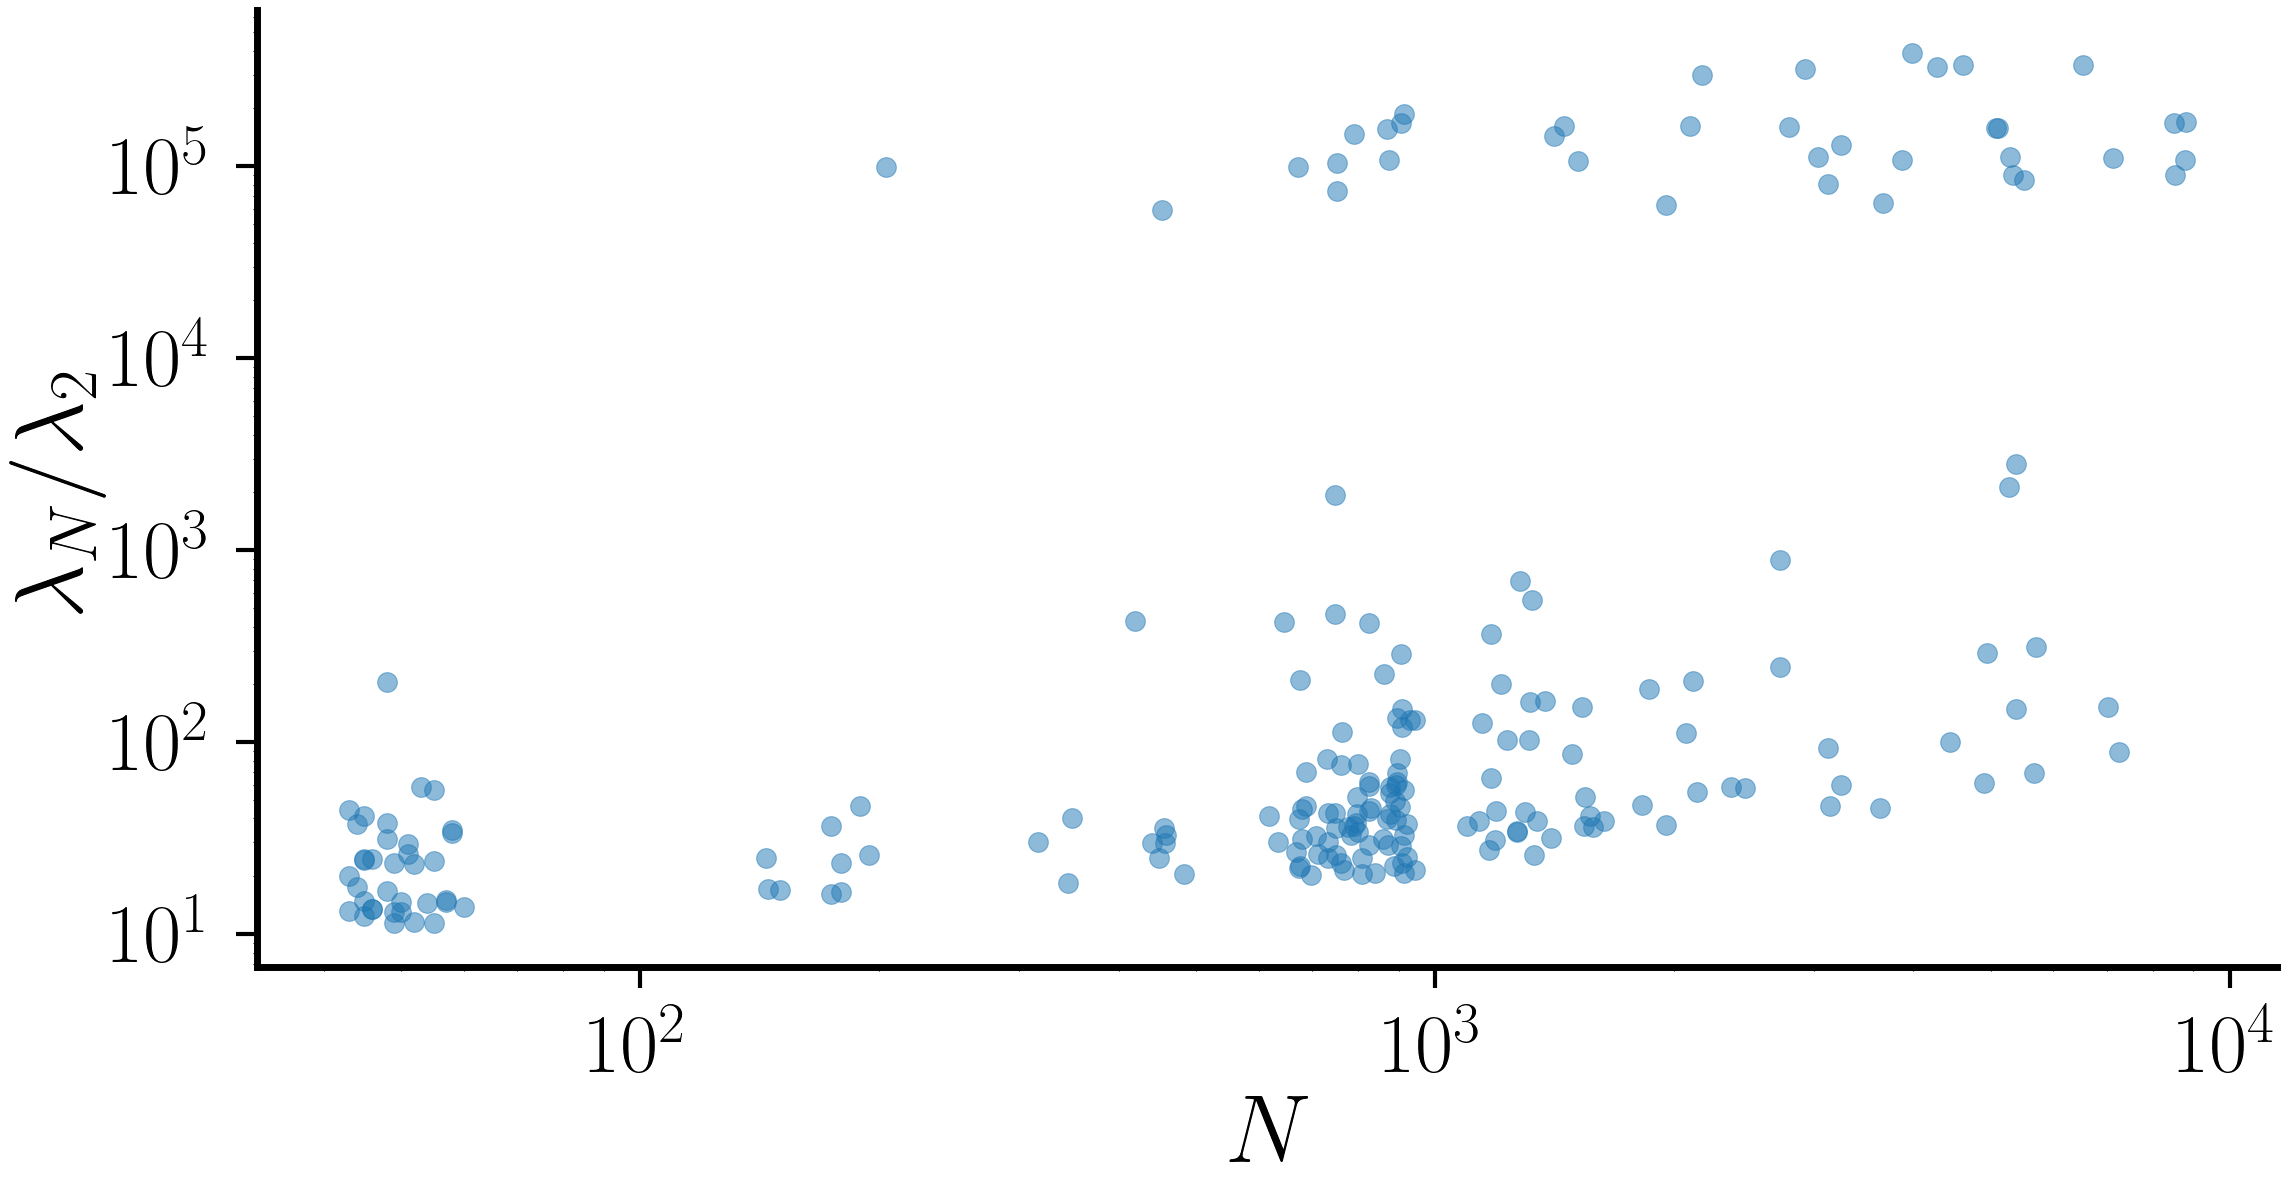

In [7]:
fig = plt.figure()
ax = fig.add_subplot(111)

for axis in ['bottom','left']:
  ax.spines[axis].set_linewidth(5)
for axis in ['top','right']:
  ax.spines[axis].set_visible(False)

ax.get_xaxis().tick_bottom()
ax.get_yaxis().tick_left()

fig.set_size_inches(23,12)
plt.xticks(fontsize = 60)
plt.yticks(fontsize = 60)
plt.xlabel(r'$N$',fontsize = 70)
plt.ylabel(r'$\lambda_N/\lambda_2$',fontsize = 70)

plt.scatter(data[0,:], data[1,:], s=200, marker='o', color=tableau20[0], alpha=.5)

ax.set_yscale('log')
ax.set_xscale('log')

#plt.legend(loc='upper left', frameon=False, prop={'size':45}, ncol=2)#, bbox_to_anchor=(0, .9))

#plt.xlim([1,1200])
#plt.ylim([10,1000])
plt.gca().tick_params(axis='y', pad=15, size=15, width=3)
plt.gca().tick_params(axis='x', pad=20, size=15, width=3)

#plt.tight_layout()
fig.set_tight_layout(True)
plt.savefig('eigen_ratio.pdf')